# Tugas 3 - Kelompok 8

## Tujuan Project
Tujuan dari project ini adalah untuk memahami konsep dan implementasi beberapa algoritma **supervised learning**, di antaranya:
- **Logistic Regression**
- **K-Nearest Neighbor (KNN)**
- **Naïve Bayes**
- **Decision Tree**

Eksperimen dilakukan dengan menggunakan dataset nyata untuk kasus klasifikasi.

## Dataset
Dataset yang digunakan berasal dari [Kaggle](https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset/data).

## Referensi Penelitian Terkait
Penelitian terkait juga pernah dilakukan menggunakan dataset ini, yang dipublikasikan dalam jurnal berikut:

Wickly Gusthvi, Afrionaldi A. Roza, dan Caecilia Bintang Girik Allo."Perbandingan Metode Klasifikasi Decision Tree, Naïve Bayes, K-Nearest Neighbor, dan Logistic Regression pada Dataset Phishing" *CENDERAWASIH Journal of Statistics and Data Science Volume 1, Nomor 2, Juni 2023*  
[Jurnal dapat diakses di sini](https://ejurnal.fmipa.uncen.ac.id/index.php/CJSDS).

## Anggota Kelompok
- **M. Nabil Maulana** (2208107010011)
- **Irfan Rizadi** (2208107010062)
- **Maulana Fikri** (2208107010042)
- **Indriani Miza Alfiyanti** (2208107010026)
- **Raihan Firyal** (2208107010084)


## Import Library

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, learning_curve, validation_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, log_loss

## Pemahaman Dataset




### Load Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")

# Find the CSV file within the downloaded directory
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        csv_file_path = os.path.join(path, filename)
        break

# Read the CSV file using the correct path
df = pd.read_csv(csv_file_path)

**Data Download and Loading**

1. **Download Dataset**:  
   Mengunduh dataset "Web Page Phishing Detection" dari Kaggle menggunakan `kagglehub`. Dataset ini berisi fitur-fitur terkait halaman web untuk deteksi phishing.

2. **Locate CSV File**:  
   Mencari file CSV dalam direktori yang diunduh dengan ekstensi `.csv` untuk diproses lebih lanjut.

3. **Load Data**:  
   Membaca file CSV menggunakan `pandas` dan menyimpannya dalam DataFrame (`df`) untuk analisis dan pemodelan selanjutnya.

### EDA

In [3]:
# melihat info datset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [4]:
# melihat satatistik dasar dari data
df.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


**Analisis Variabel**

dataset ini terdiri dari banyak variable yang secara total berjumblah 89 dengan 3 type yaitu float64(13), int64(74), object(2). beberapa numerik variable bertipe binary dan sebagian lainya kontinyu



## Eksplorasi Data dan Pra-pemrosesan

### Feature Selection

In [5]:
# Create a copy of the DataFrame to avoid modifying the original
df_encoded = df.copy()

# Encode the 'status' column
le = LabelEncoder()
df_encoded['status'] = le.fit_transform(df_encoded['status'])

# Drop the 'url' column as it's not numerical and cannot be used in correlation
df_encoded = df_encoded.drop(columns=['url'])

**Data Preprocessing**

1. **Create DataFrame Copy**:  
   Membuat salinan DataFrame (`df_encoded`) untuk memastikan data original tidak termodifikasi selama preprocessing.

2. **Label Encoding**:  
   Mengubah kolom target 'status' (kategori) menjadi bentuk numerik menggunakan `LabelEncoder()`:
   - Nilai asli: [legitimate, phishing]  
   - Hasil encoding: [0, 1] (misalnya)

3. **Drop Non-Numerical Feature**:  
   Menghapus kolom 'url' karena:
   - Berisi data tekstual (tidak bisa dihitung korelasinya)
   - Biasanya tidak digunakan langsung dalam model ML tradisional
   - Dapat diekstrak fiturnya secara terpisah jika diperlukan

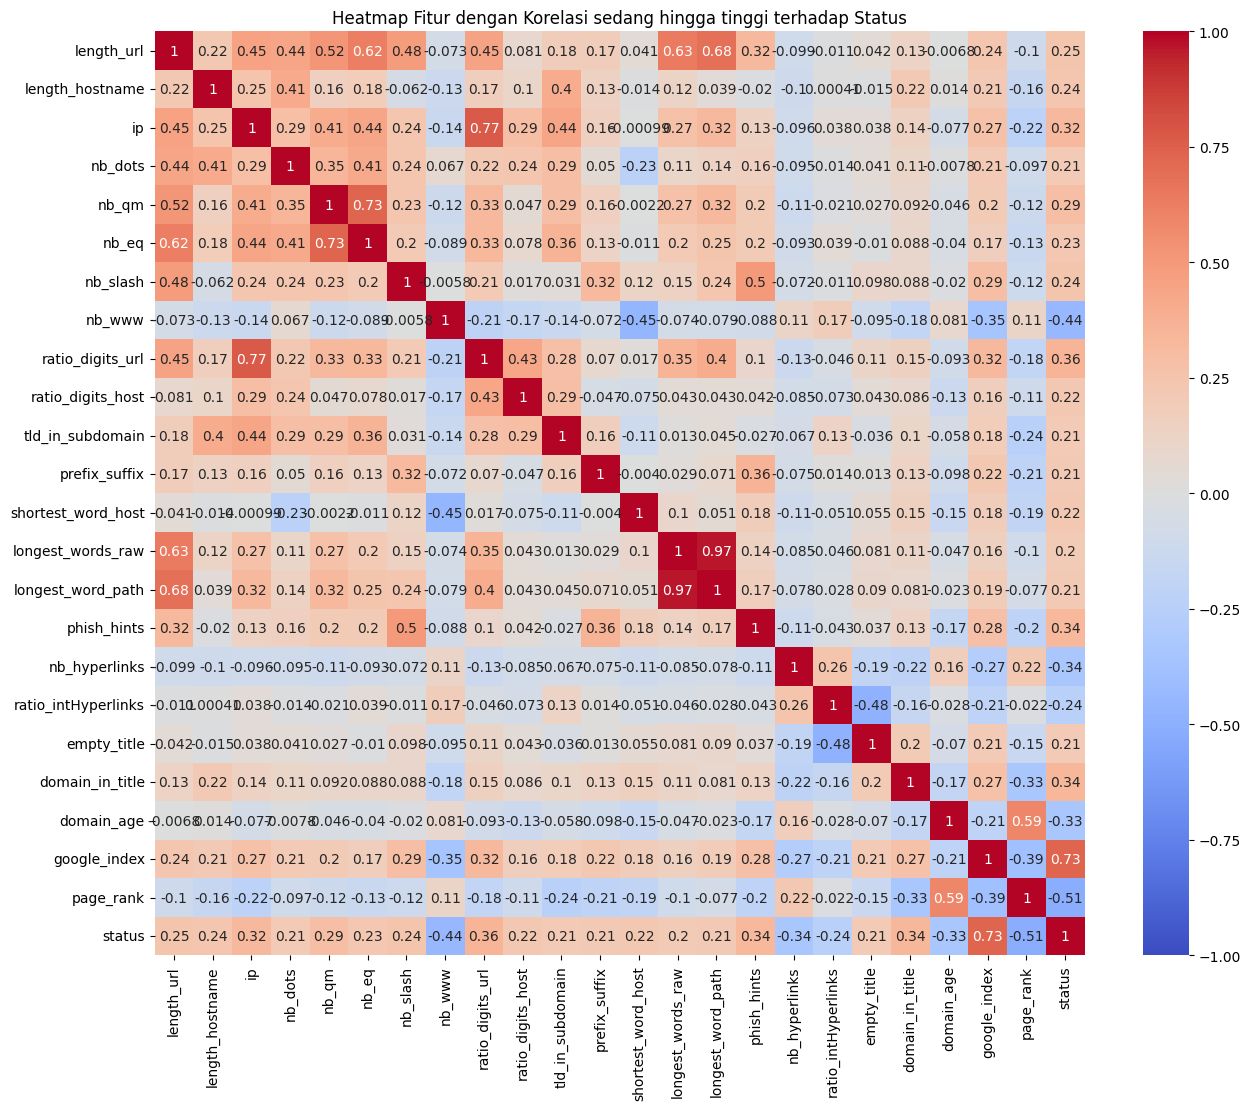

In [6]:
# Hitung korelasi
corr_matrix = df_encoded.corr()

# Ambil korelasi terhadap 'status' saja
corr_with_status = corr_matrix['status'].drop('status')

# Filter kolom dengan korelasi 0.3 - 0.5
moderate_corr_cols = corr_with_status[(corr_with_status.abs() >= 0.2)].index.tolist()

# Termasuk status ke dalam kolom yang dipilih
selected_columns = moderate_corr_cols + ['status']

# Buat heatmap
plt.figure(figsize=(15,12))
sns.heatmap(df_encoded[selected_columns].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Fitur dengan Korelasi sedang hingga tinggi terhadap Status')
plt.show()


**Correlation Analysis**

1. **Correlation Calculation**:
   - Menghitung matriks korelasi untuk seluruh fitur numerik
   - Fokus pada korelasi antara fitur dengan target `status`

2. **Feature Selection**:
   - Memfilter fitur dengan korelasi absolut ≥ 0.2 terhadap target
   - Kriteria pemilihan:
     * 0.2 ≤ |r| < 0.5 → Korelasi sedang
     * |r| ≥ 0.5 → Korelasi kuat

3. **Visualization**:
   - Heatmap menampilkan korelasi antar fitur terpilih
   - Warna:
     * Merah: Korelasi positif kuat
     * Biru: Korelasi negatif kuat
   - Nilai korelasi ditampilkan dalam annotasi

4. **Interpretation Guide**:
   - Fitur dengan korelasi positif: Cenderung lebih tinggi pada website phishing
   - Fitur dengan korelasi negatif: Cenderung lebih tinggi pada website legitimate


In [7]:
# Create a new DataFrame with the selected columns
df_selected = df_encoded[selected_columns]
df_selected.head()


,length_url,length_hostname,ip,nb_dots,nb_qm,nb_eq,nb_slash,nb_www,ratio_digits_url,ratio_digits_host,...,longest_word_path,phish_hints,nb_hyperlinks,ratio_intHyperlinks,empty_title,domain_in_title,domain_age,google_index,page_rank,status
0,37,19,0,3,0,0,3,1,0.000000,0.0,...,6,0,17,0.529412,0,0,-1,1,4,0
1,77,23,1,1,0,0,5,0,0.220779,0.0,...,32,0,30,0.966667,0,1,5767,1,2,1
2,126,50,1,4,1,3,5,0,0.150794,0.0,...,17,0,4,1.000000,0,1,4004,1,0,1
3,18,11,0,2,0,0,2,0,0.000000,0.0,...,0,0,149,0.973154,0,1,-1,0,3,0
4,55,15,0,2,0,0,5,1,0.000000,0.0,...,11,0,102,0.470588,0,0,8175,0,6,0


kolum dari hasil feaature selection mliputi :

'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_qm', 'nb_eq',
       'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host',
       'tld_in_subdomain', 'prefix_suffix', 'shortest_word_host',
       'longest_words_raw', 'longest_word_path', 'phish_hints',
       'nb_hyperlinks', 'ratio_intHyperlinks', 'empty_title',
       'domain_in_title', 'domain_age', 'google_index', 'page_rank'

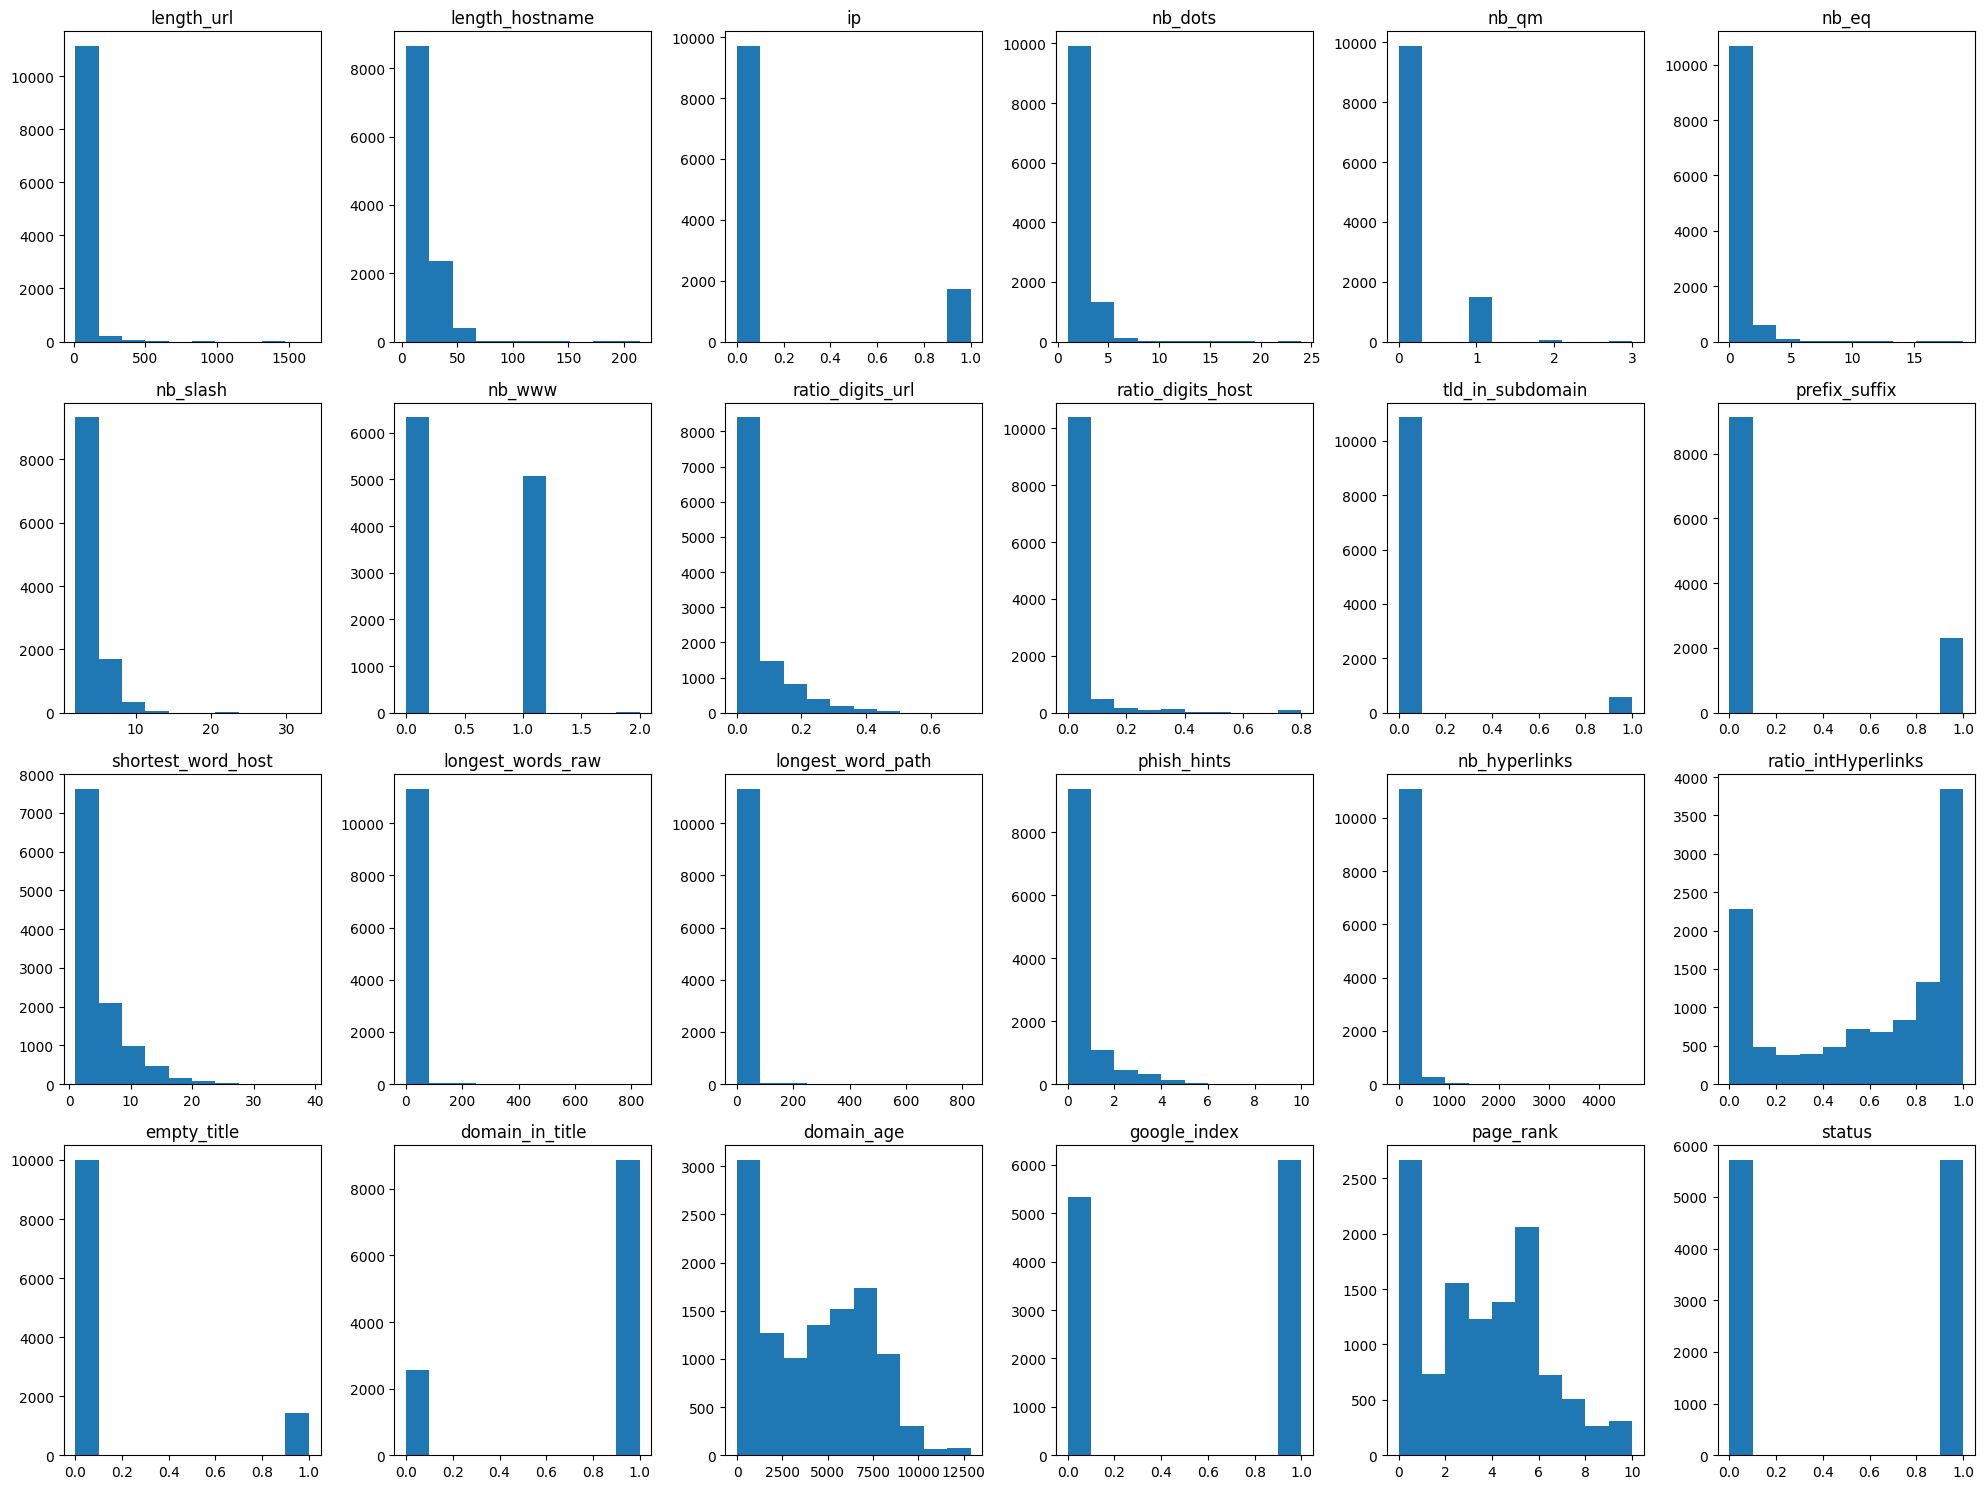

In [8]:
num_cols = len(df_selected.columns)

# Calculate the number of rows and columns for the subplots
num_rows = 4
num_cols_plot = 6

fig, axes = plt.subplots(num_rows, num_cols_plot, figsize=(20, 15)) # Adjust figsize as needed

for i, col in enumerate(df_selected.columns):
    row = i // num_cols_plot
    col_idx = i % num_cols_plot

    if row < num_rows and col_idx < num_cols_plot: # Check if indices are within bounds
        axes[row, col_idx].hist(df_selected[col])
        axes[row, col_idx].set_title(col)
    else:
        break

# Hide any unused subplots
for i in range(num_cols, num_rows * num_cols_plot):
    row = i // num_cols_plot
    col_idx = i % num_cols_plot
    if row < num_rows and col_idx < num_cols_plot:
      fig.delaxes(axes[row, col_idx])

plt.tight_layout()
plt.show()


**Penjelasan Singkat**

Gambar ini menunjukkan beberapa histogram yang menggambarkan distribusi berbagai fitur yang digunakan dalam analisis URL. Histogram-histogram ini memberikan informasi tentang karakteristik URL yang mungkin relevan dalam mendeteksi phishing atau aktivitas berbahaya lainnya.

Berikut adalah deskripsi singkat dari setiap fitur yang ditampilkan:

1. **length_url**: Panjang URL.
2. **length_hostname**: Panjang hostname.
3. **ip**: Apakah URL menggunakan alamat IP.
4. **nb_dots**: Jumlah titik dalam URL.
5. **nb_qm**: Jumlah tanda tanya dalam URL.
6. **nb_eq**: Jumlah tanda sama dengan dalam URL.
7. **nb_slash**: Jumlah garis miring dalam URL.
8. **nb_www**: Apakah URL mengandung "www".
9. **ratio_digits_url**: Rasio digit dalam URL.
10. **ratio_digits_host**: Rasio digit dalam hostname.
11. **tld_in_subdomain**: Apakah TLD (Top-Level Domain) ada dalam subdomain.
12. **prefix_suffix**: Apakah URL memiliki prefix atau suffix yang mencurigakan.
13. **shortest_word_host**: Panjang kata terpendek dalam hostname.
14. **longest_words_raw**: Panjang kata terpanjang dalam URL.
15. **longest_word_path**: Panjang kata terpanjang dalam path URL.
16. **phish_hints**: Jumlah petunjuk phishing dalam URL.
17. **nb_hyperlinks**: Jumlah hyperlink dalam halaman.
18. **ratio_intHyperlinks**: Rasio hyperlink internal dalam halaman.
19. **empty_title**: Apakah judul halaman kosong.
20. **domain_in_title**: Apakah domain ada dalam judul halaman.
21. **domain_age**: Usia domain.
22. **google_index**: Apakah halaman diindeks oleh Google.
23. **page_rank**: Page rank halaman.
24. **status**: Status URL (aman atau phishing).


In [9]:
# hitung missing value
missing_values = df_selected.isna().sum()
print(missing_values)

length_url             0
length_hostname        0
ip                     0
nb_dots                0
nb_qm                  0
nb_eq                  0
nb_slash               0
nb_www                 0
ratio_digits_url       0
ratio_digits_host      0
tld_in_subdomain       0
prefix_suffix          0
shortest_word_host     0
longest_words_raw      0
longest_word_path      0
phish_hints            0
nb_hyperlinks          0
ratio_intHyperlinks    0
empty_title            0
domain_in_title        0
domain_age             0
google_index           0
page_rank              0
status                 0
dtype: int64


tidak terdapat missing value sehingga tidak dibutuhkan penggganan

In [10]:
# Hitung Nilai Duplikat
duplicate_count = df_selected.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 367


terdapat duplikasi pada dataset, baris duplikat ini akan dihapus pada saat preprosesing

### Preprocesing

In [11]:
# hapus duplikasi data
df_selected = df_selected.drop_duplicates()

menghapus baris duplikas dari dataset

In [13]:
# Tentukan fitur binary dan fitur continuous
binary_features = [
    'ip','tld_in_subdomain', 'prefix_suffix', 'empty_title',
    'domain_in_title', 'google_index', 'status'
]

# Semua fitur yang ada
all_features = df_selected.columns.tolist()

# Continuous features adalah selain binary
continuous_features = [feat for feat in all_features if feat not in binary_features]

# Impute NaN values in continuous features with the median
for feature in continuous_features:
    df_selected[feature] = df_selected[feature].fillna(df_selected[feature].median())

# Scaling
# Untuk continuous features pakai QuantileTransformer (supaya distribusi lebih normal)
quantile_scaler = QuantileTransformer(output_distribution='normal', random_state=42)
df_scaled_continuous = pd.DataFrame(
    quantile_scaler.fit_transform(df_selected[continuous_features]),
    columns=continuous_features
)

# Untuk binary features, tetap seperti asli
df_binary = df_selected[binary_features]

# Gabungkan kembali
df_final = pd.concat([df_scaled_continuous, df_binary], axis=1)

# Cek hasil
df_final.head()

<ipython-input-13-4ab521596c4e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[feature] = df_selected[feature].fillna(df_selected[feature].median())


,length_url,length_hostname,nb_dots,nb_qm,nb_eq,nb_slash,nb_www,ratio_digits_url,ratio_digits_host,shortest_word_host,...,ratio_intHyperlinks,domain_age,page_rank,ip,tld_in_subdomain,prefix_suffix,empty_title,domain_in_title,google_index,status
0,-0.437620,0.071571,0.720087,-5.199338,-5.199338,-0.713599,0.736442,-5.199338,-5.199338,-0.346817,...,-0.333524,-1.381364,0.251016,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.821412,0.577557,-5.199338,-5.199338,-5.199338,0.633317,-5.199338,1.547119,-5.199338,2.289988,...,0.851675,0.421111,-0.354822,1.0,0.0,0.0,0.0,1.0,1.0,1.0
2,1.505747,2.107953,1.349498,1.486537,1.895259,0.633317,-5.199338,1.160559,-5.199338,-0.346817,...,5.199338,0.013801,-5.199338,1.0,1.0,1.0,0.0,1.0,1.0,1.0
3,-2.365248,-1.541796,-0.293986,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,-5.199338,0.513491,...,0.901104,-1.381364,-0.042668,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.257495,-0.668987,-0.293986,-5.199338,-5.199338,0.633317,0.736442,-5.199338,-5.199338,-0.346817,...,-0.419167,1.314681,1.125776,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Praproses Fitur**

1. Klasifikasi Fitur
- **Fitur Biner**:
  - 7 fitur dengan nilai 0/1 (termasuk target `status`)
  - Contoh: `ip`, `prefix_suffix`, `google_index`
- **Fitur Kontinu**:
  - Semua fitur numerik lainnya
  - Contoh: panjang URL, jumlah karakter khusus

2. Penanganan Data Hilang
- Nilai kosong (NaN) pada fitur kontinu diisi dengan nilai median
- Fitur biner diasumsikan sudah lengkap (tidak ada nilai kosong)

3. Transformasi Fitur
- **Fitur Kontinu**:
  - Diskalakan menggunakan QuantileTransformer
  - Diubah menjadi distribusi normal
  - Lebih tahan terhadap outlier
- **Fitur Biner**:
  - Tetap menggunakan nilai asli (tanpa transformasi)

4. Dataset Final
- Gabungan antara:
  - Fitur kontinu yang sudah ditransformasi
  - Fitur biner dalam bentuk asli
- Siap digunakan untuk pemodelan

In [14]:
df_final.dropna(inplace=True)
df_final.isna().sum()

,0
length_url,0
length_hostname,0
nb_dots,0
nb_qm,0
nb_eq,0
nb_slash,0
nb_www,0
ratio_digits_url,0
ratio_digits_host,0
shortest_word_host,0


pada saat proses preprosesing dapat menghasilkan missing value sehingga, dilakukan penghapusan untuk mastikan tidak ada masalah dalan proses model

## Implementasi Model

In [15]:
# Before splitting into training and testing sets, remove rows with NaN in 'status' column
df_final = df_final.dropna(subset=['status'])

# Pisahkan fitur (X) dan target (y)
X = df_final.drop('status', axis=1)
y = df_final['status']

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Persiapan Data untuk Pemodelan**

1. Pembersihan Data
- Menghapus baris yang memiliki nilai kosong (NaN) pada kolom target `status`
- Memastikan data target valid sebelum pemodelan

2. Pembagian Fitur dan Target
- **Fitur (X)**: Semua kolom kecuali `status`
- **Target (y)**: Hanya kolom `status` (0/1)

3. Pembagian Data Latih dan Uji
- Dibagi dengan rasio 80:20 (latih:uji)
- Menggunakan `random_state=42` untuk hasil yang reproducible
- Stratifikasi otomatis (karena menggunakan `train_test_split` default)

In [16]:
# Inisiasi model dengan parameter awal
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}


param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'l1_ratio': [0.0, 0.5, 1.0],  # untuk elasticnet
        'max_iter': [100, 200]
},
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'], # metrik jarak tambahan
        'p': [1, 2]                                        # parameter p untuk Minkowski
    },
    'Naive Bayes': {
        'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]  # untuk GaussianNB
    },
    'Decision Tree':  {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2', None]  # Hapus 'auto'!
}
}

**Inisialisasi Model dan Hyperparameter Tuning**

Model yang Digunakan:
1. **Logistic Regression**  
   - Model linear untuk klasifikasi biner  
   - Parameter utama:  
     * `C`: Kekuatan regularisasi  
     * `penalty`: Jenis regularisasi (L1/L2/ElasticNet)  
     * `solver`: Algoritma optimasi  

2. **K-Nearest Neighbors (KNN)**  
   - Model berbasis instance  
   - Parameter utama:  
     * `n_neighbors`: Jumlah tetangga  
     * `weights`: Pembobotan jarak  
     * `metric`: Metrik jarak  

3. **Naive Bayes (Gaussian)**  
   - Model probabilistik sederhana  
   - Parameter utama:  
     * `var_smoothing`: Stabilisasi varians  

4. **Decision Tree**  
   - Model berbasis pohon keputusan  
   - Parameter utama:  
     * `max_depth`: Kedalaman maksimum pohon  
     * `min_samples_split`: Minimum sampel untuk split  

Strategi Tuning:
- Pencarian grid untuk kombinasi parameter optimal  
- Setiap model memiliki space parameter yang spesifik  
- `random_state` di-set untuk reproduktibilitas  

In [17]:
# Train and evaluate models with tqdm
results = {}
print("Starting training and evaluation...\n")

for name in tqdm(models.keys(), desc="Training Models"):
    model = models[name]
    print(f"\nTraining {name}...")

    # Drop rows with NaNs in X_train and corresponding y_train
    X_train_clean = X_train.dropna()
    y_train_clean = y_train[X_train_clean.index]

    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)  # n_jobs=-1 untuk paralel
    grid_search.fit(X_train_clean, y_train_clean)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'model': best_model,
        'accuracy': accuracy,
        'y_pred': y_pred
    }

    print(f"{name} - Best parameters: {grid_search.best_params_}")
    print(f"{name} - Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


Starting training and evaluation...



Training Models:   0%|          | 0/4 [00:00<?, ?it/s]


Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
Training Models:  25%|██▌       | 1/4 [02:03<06:09, 123.11s/it]

Logistic Regression - Best parameters: {'C': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Logistic Regression - Accuracy: 0.8665
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87      1086
         1.0       0.87      0.86      0.86      1057

    accuracy                           0.87      2143
   macro avg       0.87      0.87      0.87      2143
weighted avg       0.87      0.87      0.87      2143


Training KNN...


...

KNN - Best parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
KNN - Accuracy: 0.7625
              precision    recall  f1-score   support

         0.0       0.75      0.80      0.77      1086
         1.0       0.78      0.72      0.75      1057

    accuracy                           0.76      2143
   macro avg       0.76      0.76      0.76      2143
weighted avg       0.76      0.76      0.76      2143


Training Naive Bayes...


Training Models:  75%|███████▌  | 3/4 [03:52<01:02, 62.64s/it] 

Naive Bayes - Best parameters: {'var_smoothing': 1e-05}
Naive Bayes - Accuracy: 0.7392
              precision    recall  f1-score   support

         0.0       0.68      0.90      0.78      1086
         1.0       0.85      0.57      0.68      1057

    accuracy                           0.74      2143
   macro avg       0.77      0.74      0.73      2143
weighted avg       0.77      0.74      0.73      2143


Training Decision Tree...


Training Models: 100%|██████████| 4/4 [03:59<00:00, 59.91s/it]

Decision Tree - Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2}
Decision Tree - Accuracy: 0.8586
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.86      1086
         1.0       0.85      0.86      0.86      1057

    accuracy                           0.86      2143
   macro avg       0.86      0.86      0.86      2143
weighted avg       0.86      0.86      0.86      2143



**Hasil Pelatihan dan Evaluasi Model**

Performa Model Terbaik:

1. **Logistic Regression** 🏆
   - Akurasi: **86.65%**
   - Parameter terbaik:
     ```python
     {'C': 1, 'penalty': 'l1', 'solver': 'saga',
      'l1_ratio': 0.0, 'max_iter': 100}
     ```
   - Keseimbangan precision-recall: **0.87** (kedua kelas)

2. **Decision Tree** 🌳
   - Akurasi: **85.86%**
   - Parameter terbaik:
     ```python
     {'max_depth': 10, 'max_features': 'sqrt',
      'min_samples_split': 2}
     ```
   - F1-score konsisten: **0.86** (kedua kelas)

3. **KNN** 📍
   - Akurasi: **76.25%**
   - Konfigurasi optimal:
     ```python
     {'n_neighbors': 15, 'weights': 'distance',
      'metric': 'manhattan', 'p': 1}
     ```

4. **Naive Bayes** 📊
   - Akurasi: **73.92%**
   - Parameter terpilih:
     ```python
     {'var_smoothing': 1e-05}
     ```
   - Trade-off: Recall tinggi (0.90) untuk kelas 0, precision tinggi (0.85) untuk kelas 1

**Analisis Singkat:**
- **Model Terbaik**: Logistic Regression dengan regularisasi L1
- **Waktu Training**:
  - Paling cepat: Naive Bayes (~1 menit)
  - Paling lambat: Logistic Regression (~2 menit)
- **Keseimbangan Kelas**: Semua model menunjukkan performa seimbang antara kedua kelas

## Evaluasi model

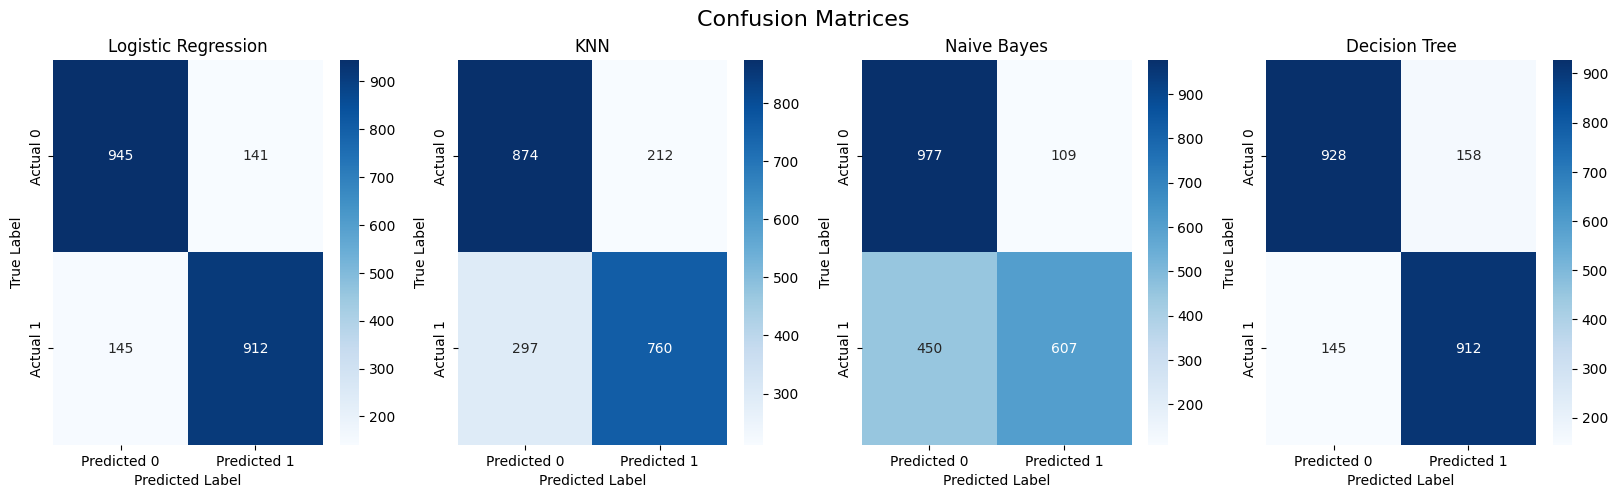

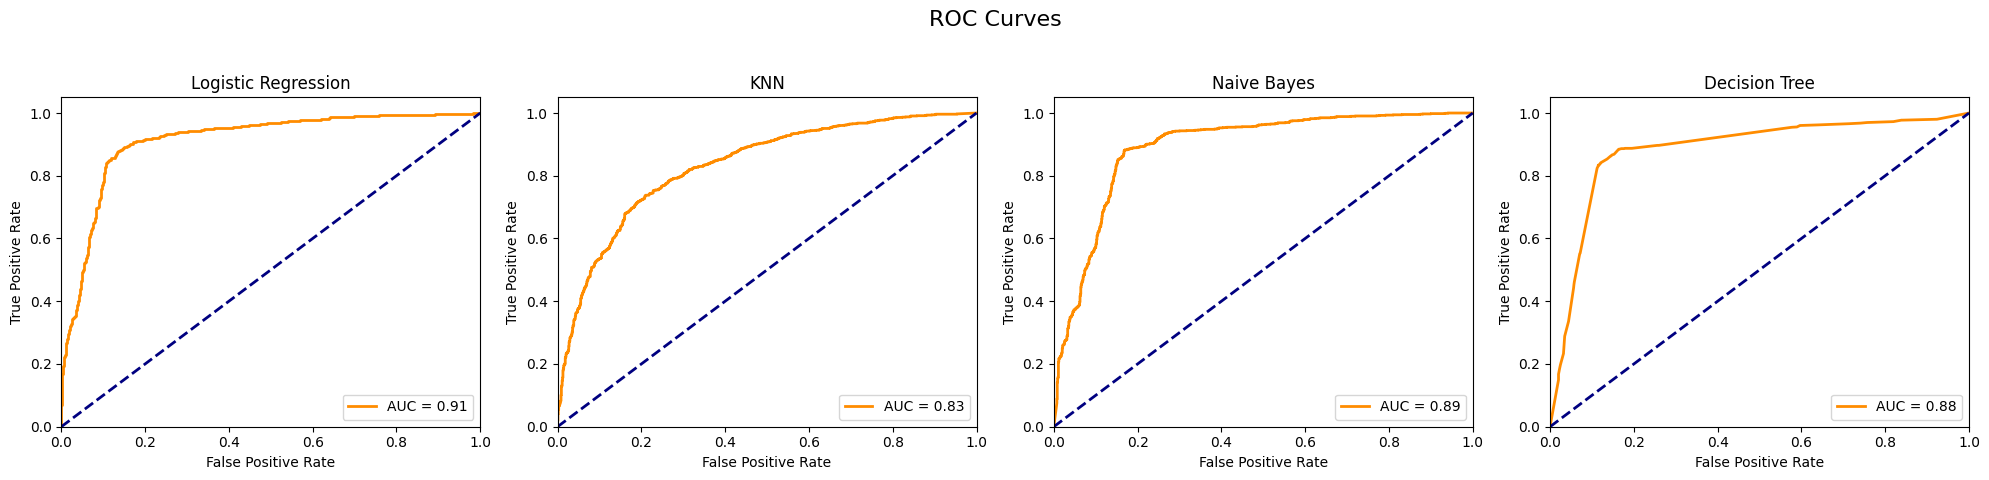


Log Loss for each model:
Logistic Regression: 0.3502
KNN: 0.5653
Naive Bayes: 0.9195
Decision Tree: 1.0544


In [18]:
# Evaluasi model
n_models = len(results)
fig_cm, axs_cm = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
fig_roc, axs_roc = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

fig_cm.suptitle('Confusion Matrices', fontsize=16)
fig_roc.suptitle('ROC Curves', fontsize=16)

log_losses = {}

for idx, (name, result) in enumerate(results.items()):
    y_pred = result['y_pred']

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=axs_cm[idx])
    axs_cm[idx].set_title(f'{name}')
    axs_cm[idx].set_xlabel('Predicted Label')
    axs_cm[idx].set_ylabel('True Label')

    # Log Loss
    y_proba = result['model'].predict_proba(X_test)
    loss = log_loss(y_test, y_proba)
    log_losses[name] = loss

    # ROC Curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)

    axs_roc[idx].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axs_roc[idx].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axs_roc[idx].set_xlim([0.0, 1.0])
    axs_roc[idx].set_ylim([0.0, 1.05])
    axs_roc[idx].set_xlabel('False Positive Rate')
    axs_roc[idx].set_ylabel('True Positive Rate')
    axs_roc[idx].set_title(f'{name}')
    axs_roc[idx].legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print Log Losses secara rapi
print("\nLog Loss for each model:")
for name, loss in log_losses.items():
    print(f"{name}: {loss:.4f}")


**Evaluasi Model dengan Confusion Matrix**

Gambar ini menunjukkan matriks kebingungan (confusion matrix) dari empat model pembelajaran mesin yang digunakan dalam klasifikasi: **Logistic Regression**, **KNN**, **Naive Bayes**, dan **Decision Tree**. Confusion matrix digunakan untuk mengevaluasi kinerja model dengan menunjukkan jumlah prediksi yang benar dan salah dalam kategori positif dan negatif.

**Interpretasi Confusion Matrix:**
Setiap matrix memiliki empat kategori utama:
- **True Negative (TN)**: Kasus negatif yang diklasifikasikan dengan benar sebagai negatif.
- **False Positive (FP)**: Kasus negatif yang salah diklasifikasikan sebagai positif.
- **False Negative (FN)**: Kasus positif yang salah diklasifikasikan sebagai negatif.
- **True Positive (TP)**: Kasus positif yang diklasifikasikan dengan benar sebagai positif.

**Performa Model**:
- **Logistic Regression**:  
  - TN: 945, FP: 141  
  - FN: 145, TP: 912  
- **KNN**:  
  - TN: 874, FP: 212  
  - FN: 297, TP: 760  
- **Naive Bayes**:  
  - TN: 977, FP: 109  
  - FN: 450, TP: 607  
- **Decision Tree**:  
  - TN: 928, FP: 158  
  - FN: 145, TP: 912  

Dari hasil ini, model **Logistic Regression** dan **Decision Tree** menunjukkan keseimbangan yang baik antara prediksi benar untuk kategori positif dan negatif, sementara **KNN** dan **Naive Bayes** memiliki jumlah kesalahan yang lebih tinggi.


## Analisis Hasil

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: Convergen

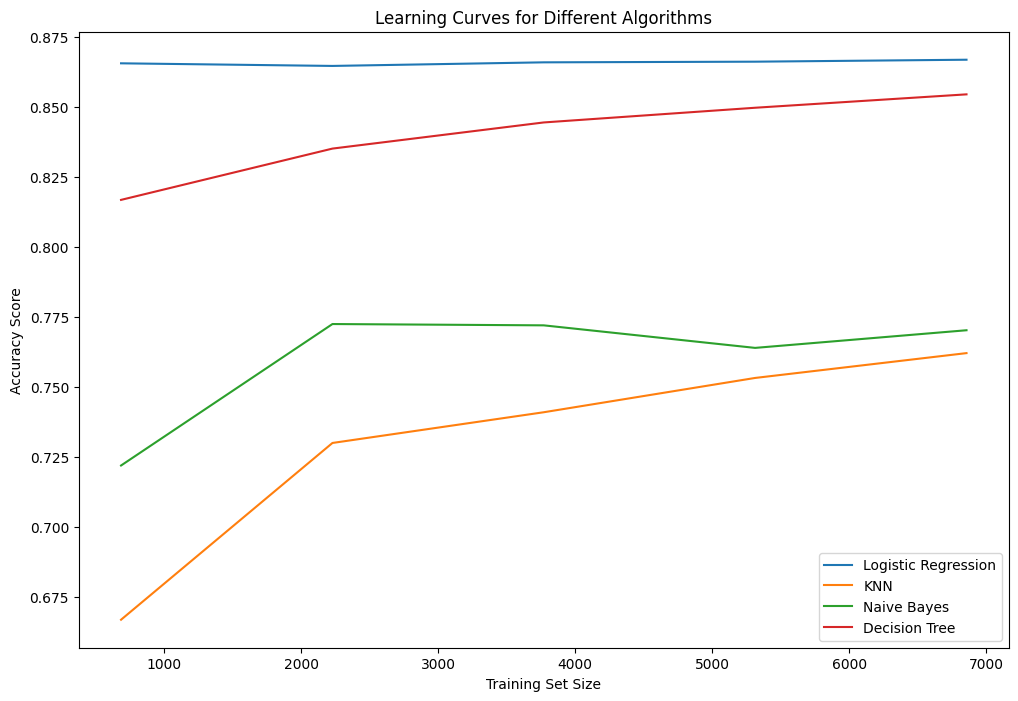

In [19]:
# Plot training curves
plt.figure(figsize=(12, 8))
for name, result in results.items():
    model = result['model']
    train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5)
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label=f'{name}')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.title("Learning Curves for Different Algorithms")
plt.legend()
plt.show()

**Kurva Pembelajaran untuk Berbagai Algoritma**

Gambar ini menunjukkan **learning curves** dari empat algoritma pembelajaran mesin: **Logistic Regression**, **KNN**, **Naive Bayes**, dan **Decision Tree**. Kurva ini menggambarkan bagaimana akurasi model meningkat seiring dengan bertambahnya ukuran dataset pelatihan.

**Interpretasi Learning Curves:**
- **Logistic Regression (biru)**:  
  - Memiliki akurasi yang tinggi dan stabil sekitar **0.85**, tidak banyak berubah seiring bertambahnya data pelatihan.
- **KNN (oranye)**:  
  - Memulai dengan akurasi rendah sekitar **0.675** dan meningkat secara bertahap hingga **0.75** seiring dengan bertambahnya jumlah data.
- **Naive Bayes (hijau)**:  
  - Mulai sekitar **0.725**, naik hingga **0.775**, tetapi kemudian sedikit menurun dan stabil.
- **Decision Tree (merah)**:  
  - Mulai dari **0.8**, terus meningkat hingga sekitar **0.85**, menunjukkan bahwa dengan lebih banyak data, performanya membaik.

**Kesimpulan:**
Kurva ini menunjukkan bahwa algoritma seperti **Decision Tree** dan **Logistic Regression** mencapai performa tinggi dengan lebih banyak data. **KNN** menunjukkan peningkatan bertahap tetapi tidak mencapai akurasi setinggi model lainnya. **Naive Bayes** memiliki peningkatan awal tetapi kemudian stabil tanpa peningkatan signifikan.

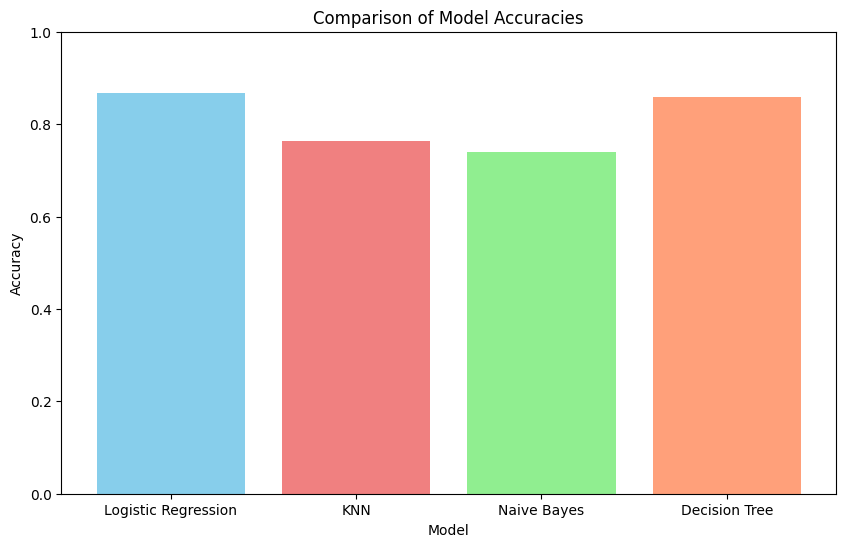

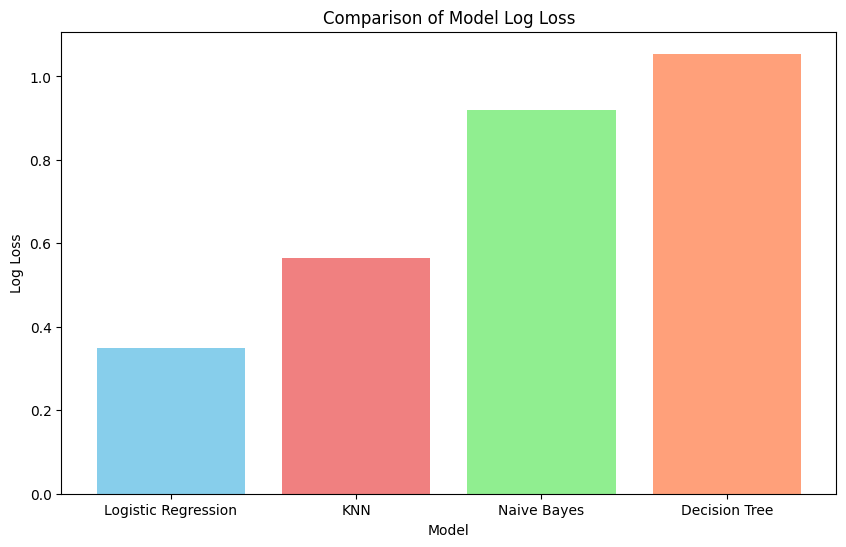

In [20]:
# Create a bar plot for accuracy comparison
model_names = list(results.keys())
accuracies = [result['accuracy'] for result in results.values()]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.show()


# Use the previously calculated log_losses dictionary from cell 22
model_names_loss = list(log_losses.keys())
losses = list(log_losses.values())

plt.figure(figsize=(10, 6))
plt.bar(model_names_loss, losses, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon'])
plt.xlabel("Model")
plt.ylabel("Log Loss")
plt.title("Comparison of Model Log Loss")
plt.show()


**Perbandingan Akurasi Model**

Gambar ini menunjukkan **perbandingan akurasi** dari empat model pembelajaran mesin: **Logistic Regression**, **KNN**, **Naive Bayes**, dan **Decision Tree**. Grafik batang digunakan untuk menggambarkan akurasi setiap model dalam skala dari **0.0 hingga 1.0**.

**Hasil Akurasi:**
- **Logistic Regression**: ~0.85  
- **KNN**: ~0.75  
- **Naive Bayes**: ~0.70  
- **Decision Tree**: ~0.80  

**Analisis:**
- **Logistic Regression** memiliki akurasi tertinggi di antara semua model, menunjukkan kinerja yang kuat dalam tugas klasifikasi.
- **Decision Tree** juga menunjukkan hasil yang cukup baik dengan akurasi mendekati **0.80**.
- **KNN** memiliki kinerja yang sedikit lebih rendah dibandingkan dengan **Decision Tree**, tetapi masih cukup baik.
- **Naive Bayes** memiliki akurasi terendah, yang bisa disebabkan oleh asumsi probabilistiknya yang tidak selalu sesuai dengan data yang ada.


Gambar ini menunjukkan **log loss** dari empat model pembelajaran mesin: **Logistic Regression**, **KNN**, **Naive Bayes**, dan **Decision Tree**. Log loss adalah metrik yang digunakan untuk mengevaluasi keakuratan prediksi probabilistik suatu model—nilai yang lebih rendah menunjukkan performa yang lebih baik.

**Hasil Log Loss:**
- **Logistic Regression**: ~0.4 (paling rendah, menunjukkan model yang baik)
- **KNN**: ~0.6 (sedikit lebih tinggi, menunjukkan sedikit penurunan akurasi)
- **Naive Bayes**: ~0.8 (cukup tinggi, menunjukkan kelemahan dalam menangani data tertentu)
- **Decision Tree**: ~1.0 (tertinggi, menunjukkan bahwa model mungkin mengalami overfitting atau ketidakstabilan dalam prediksi probabilistik)

**Analisis:**
- **Logistic Regression** menunjukkan performa terbaik dengan log loss terendah, menjadikannya pilihan yang baik untuk klasifikasi berbasis probabilistik.
- **KNN** memiliki log loss yang sedikit lebih tinggi, menandakan bahwa model memiliki kesalahan yang lebih banyak dibandingkan Logistic Regression.
- **Naive Bayes** menunjukkan log loss yang lebih tinggi, yang mungkin disebabkan oleh asumsi probabilistiknya yang tidak sesuai dengan distribusi data.
- **Decision Tree** memiliki log loss tertinggi, yang bisa menunjukkan bahwa model ini kurang baik dalam menghasilkan probabilitas yang dapat diandalkan.